# Lab Exercise 3 — Simple Linear Regression
### Student Survey: Scikit-learn vs. Manual OLS, and Parameter Saving

**Aim:** Use real student survey data to test whether *CIA %* and *Attendance %* can predict *GPA*, using Simple Linear Regression — once with Scikit-learn, once by hand with the OLS formulas — then compare the two and save the learned parameters with Pickle.

**Experiment 1:** CIA % (X) → GPA (Y)
**Experiment 2:** Attendance % (X) → GPA (Y)


## Part A — Data Collection and Preprocessing

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('student_survey.csv')
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


**Dataset dimensions**

In [9]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (54, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype 
---  ------                                                                                      --------------  ----- 
 0   Timestamp                                                                                   54 non-null     object
 1   Registration Number                                                                         54 non-null     object
 2   Email                                                                                       54 non-null     object
 3   Job role that you are interested in
                                                        54 non-null     object
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null     object
 5   What is the maximum 

#changing the colnames to standardize it

In [10]:
cols = {
    'Registration Number ': 'reg_no',
    'your CIA % of last semester ': 'cia_percent',
    'your GPA of last semester': 'gpa',
    'Your maximum attendance % till last semester': 'attendance_percent'
}

data = df[list(cols.keys())].rename(columns=cols).copy()
data.head(10)

,reg_no,cia_percent,gpa,attendance_percent
0,2547123,78,3.24,Option 1
1,2547122,64.78,3.2,Option 1
2,2547101,80,3.6,Option 1
3,2547156,70,3.2,92
4,2547148,68,3.4,85
5,2547155,0.7,3.5,0.87
6,2547149,0.88,3.7,Option 1
7,2547115,3.45,10,90
8,2547147,70,3.4,89
9,2547105,83,3.89,98


flagging anytime of missing values as NAN

In [11]:
placeholders = ['Option 1', 'na', 'NA', 'N/A', '-', '', ' ']
data = data.replace(placeholders, np.nan) 

print("Missing values per column (after flagging placeholders):")
print(data.isna().sum())

Missing values per column (after flagging placeholders):
reg_no                0
cia_percent           1
gpa                   1
attendance_percent    6
dtype: int64


**Converting to numeric datatype.** The CIA/GPA/Attendance columns were typed as free text in the form, so a few stray characters (extra spaces, commas) can make pandas read them as strings. `pd.to_numeric(..., errors='coerce')` converts what it can and turns anything unreadable into `NaN`.

In [12]:
for c in ['cia_percent', 'gpa', 'attendance_percent']:
    data[c] = pd.to_numeric(data[c], errors='coerce')

print("Missing values per column (after numeric conversion):")
print(data.isna().sum())
data.dtypes 

Missing values per column (after numeric conversion):
reg_no                0
cia_percent           1
gpa                   1
attendance_percent    6
dtype: int64


reg_no                 object
cia_percent           float64
gpa                   float64
attendance_percent    float64
dtype: object

**Fixing an obvious data-entry pattern.** A handful of students entered CIA/Attendance as a *fraction* instead of a *percentage* (e.g. `0.7` instead of `70`). Anything strictly between 0 and 1 in a percentage column is almost certainly this mistake, so we rescale it rather than throw it away.

**Handling an out-of-range GPA.** This university's GPA scale tops out at 4.0 — the data has 3 entries (`10`, `90`, `7.8`) that are clearly outside that range (most likely the student filled in the wrong field of the form). We treat those as invalid rather than guess at a correction.

In [13]:
for c in ['cia_percent', 'attendance_percent']:
    fraction_mask = data[c].between(0, 1, inclusive='neither') 
    data.loc[fraction_mask, c] = data.loc[fraction_mask, c] * 100

out_of_range_gpa = ~data['gpa'].between(0, 4)
print("GPA values being flagged as invalid:", data.loc[out_of_range_gpa, 'gpa'].tolist())
data.loc[out_of_range_gpa, 'gpa'] = np.nan

GPA values being flagged as invalid: [10.0, 90.0, nan, 7.8]


**Removing null values and duplicate records.** A few students submitted the form twice — we keep only their first response. Then we drop any row still missing one of our three numeric fields.

In [14]:
print("Rows before cleaning:", data.shape[0])

data_clean = data.dropna().drop_duplicates(subset='reg_no', keep='first').reset_index(drop=True)

print("Rows after dropping nulls and duplicates:", data_clean.shape[0])
data_clean.head(10)

Rows before cleaning: 54
Rows after dropping nulls and duplicates: 43


,reg_no,cia_percent,gpa,attendance_percent
0,2547156,70.00,3.20,92.0
1,2547148,68.00,3.40,85.0
2,2547155,70.00,3.50,87.0
3,2547147,70.00,3.40,89.0
4,2547105,83.00,3.89,98.0
5,2547113,70.00,3.30,97.0
6,2547145,70.00,3.50,99.0
7,2547108,70.00,3.48,97.0
8,2547122,64.67,3.40,95.0
9,2547134,70.00,2.90,90.0


**Statistical summary of the cleaned data**

In [15]:
data_clean[['cia_percent', 'gpa', 'attendance_percent']].describe()

,cia_percent,gpa,attendance_percent
count,43.000000,43.000000,43.000000
mean,71.626279,3.509302,93.833256
std,12.126630,0.255244,4.511739
min,4.000000,2.900000,85.000000
25%,70.000000,3.400000,90.000000
50%,71.000000,3.500000,95.000000
75%,78.000000,3.655000,98.000000
max,89.000000,4.000000,100.000000


**Quick visual check** — does either variable look related to GPA?

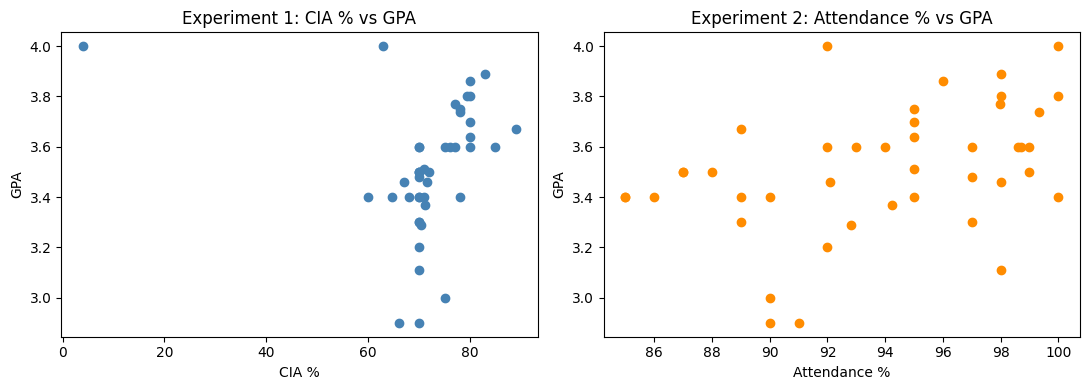

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(data_clean['cia_percent'], data_clean['gpa'], color='steelblue')
axes[0].set_xlabel("CIA %")
axes[0].set_ylabel("GPA")
axes[0].set_title("Experiment 1: CIA % vs GPA")

axes[1].scatter(data_clean['attendance_percent'], data_clean['gpa'], color='darkorange')
axes[1].set_xlabel("Attendance %")
axes[1].set_ylabel("GPA")
axes[1].set_title("Experiment 2: Attendance % vs GPA")

plt.tight_layout()
plt.show()

**Selecting dependent and independent variables**

| Exp        | Independent (X) | Dependent (Y) |

| 1 -> CIA % -> GPA |
| 2 -> Attendance % -> GPA |


In [17]:
X1 = data_clean[['cia_percent']]
y1 = data_clean['gpa']

X2 = data_clean[['attendance_percent']]
y2 = data_clean['gpa']

print("Experiment 1 — X shape:", X1.shape, " y shape:", y1.shape)
print("Experiment 2 — X shape:", X2.shape, " y shape:", y2.shape)

Experiment 1 — X shape: (43, 1)  y shape: (43,)
Experiment 2 — X shape: (43, 1)  y shape: (43,)


## Part B — Simple Linear Regression using Scikit-learn

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=2)

sk_model_1 = LinearRegression().fit(X1_train, y1_train)
sk_model_2 = LinearRegression().fit(X2_train, y2_train)

sk_pred_1 = sk_model_1.predict(X1_test)
sk_pred_2 = sk_model_2.predict(X2_test)

print("Experiment 1 (CIA% -> GPA)")
print("  Slope (m):", sk_model_1.coef_[0])
print("  Intercept (b):", sk_model_1.intercept_)

print("\nExperiment 2 (Attendance% -> GPA)")
print("  Slope (m):", sk_model_2.coef_[0])
print("  Intercept (b):", sk_model_2.intercept_)

Experiment 1 (CIA% -> GPA)
  Slope (m): -0.0019573790671469043
  Intercept (b): 3.662157970609496

Experiment 2 (Attendance% -> GPA)
  Slope (m): 0.01986250465814335
  Intercept (b): 1.657322396965987


**Model evaluation (Scikit-learn)**

In [19]:
for name, y_test, y_pred in [("Experiment 1", y1_test, sk_pred_1), ("Experiment 2", y2_test, sk_pred_2)]:
    print(f"--- {name} ---")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("R2  :", r2_score(y_test, y_pred))
    print()

--- Experiment 1 ---
MAE : 0.2222319192619053
MSE : 0.07863436844458038
R2  : -0.09926889717493537

--- Experiment 2 ---
MAE : 0.20695129552945465
MSE : 0.06052335294976205
R2  : 0.15391398485887164



## Part C — Manual Computation using Ordinary Least Squares (OLS)

**Manual Regression Equation**

$$ m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad\qquad b = \bar{y} - m\bar{x} $$

where $m$ is the slope, $b$ is the intercept, and $\bar{x}, \bar{y}$ are the column means.

In [20]:
class ManualLinearRegression:
    """Simple Linear Regression implemented from the raw OLS formulas."""

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        X_train = np.asarray(X_train, dtype=float).ravel()
        y_train = np.asarray(y_train, dtype=float).ravel()

        x_mean = X_train.mean()
        y_mean = y_train.mean()

        num = np.sum((X_train - x_mean) * (y_train - y_mean))
        den = np.sum((X_train - x_mean) ** 2)

        self.m = num / den
        self.b = y_mean - (self.m * x_mean)

        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)
        return self

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float).ravel()
        return self.m * X_test + self.b

In [21]:
print("Experiment 1 (CIA% -> GPA) — manual OLS")
manual_model_1 = ManualLinearRegression()
manual_model_1.fit(X1_train.values, y1_train.values)
manual_pred_1 = manual_model_1.predict(X1_test.values)

print("\nExperiment 2 (Attendance% -> GPA) — manual OLS")
manual_model_2 = ManualLinearRegression()
manual_model_2.fit(X2_train.values, y2_train.values)
manual_pred_2 = manual_model_2.predict(X2_test.values)

Experiment 1 (CIA% -> GPA) — manual OLS
Slope (m) = -0.0019573790671469043
Intercept (b) = 3.662157970609496

Experiment 2 (Attendance% -> GPA) — manual OLS
Slope (m) = 0.019862504658143362
Intercept (b) = 1.6573223969659856


## Comparison: Scikit-learn vs. Manual OLS

In [22]:
comparison_1 = pd.DataFrame({
    'Actual GPA': y1_test.values,
    'Sklearn Prediction': sk_pred_1,
    'Manual OLS Prediction': manual_pred_1,
    'Difference': sk_pred_1 - manual_pred_1
})
print("Experiment 1 (CIA% -> GPA)")
comparison_1

Experiment 1 (CIA% -> GPA)


,Actual GPA,Sklearn Prediction,Manual OLS Prediction,Difference
0,3.29,3.524515,3.524515,0.0
1,2.90,3.525141,3.525141,0.0
2,3.75,3.509482,3.509482,0.0
3,3.20,3.525141,3.525141,0.0
4,3.50,3.525141,3.525141,0.0
5,3.77,3.511440,3.511440,0.0
6,3.60,3.505568,3.505568,0.0
7,3.46,3.522205,3.522205,0.0
8,3.64,3.505568,3.505568,0.0


In [23]:
comparison_2 = pd.DataFrame({
    'Actual GPA': y2_test.values,
    'Sklearn Prediction': sk_pred_2,
    'Manual OLS Prediction': manual_pred_2,
    'Difference': sk_pred_2 - manual_pred_2
})
print("Experiment 2 (Attendance% -> GPA)")
comparison_2

Experiment 2 (Attendance% -> GPA)


,Actual GPA,Sklearn Prediction,Manual OLS Prediction,Difference
0,3.29,3.501159,3.501159,0.000000e+00
1,2.90,3.444948,3.444948,0.000000e+00
2,3.75,3.544260,3.544260,0.000000e+00
3,3.20,3.484673,3.484673,0.000000e+00
4,3.50,3.385360,3.385360,0.000000e+00
5,3.77,3.603649,3.603649,0.000000e+00
6,3.60,3.504535,3.504535,4.440892e-16
7,3.46,3.603848,3.603848,0.000000e+00
8,3.64,3.544260,3.544260,0.000000e+00


In [24]:
print("Max |difference| — Experiment 1:", np.max(np.abs(comparison_1['Difference'])))
print("Max |difference| — Experiment 2:", np.max(np.abs(comparison_2['Difference'])))

Max |difference| — Experiment 1: 0.0
Max |difference| — Experiment 2: 4.440892098500626e-16


**Observation:** The Scikit-learn slope/intercept and the manually-computed OLS slope/intercept are identical (the tiny difference, if any, is floating-point rounding, on the order of 1e-15). This is expected — `LinearRegression` in Scikit-learn *is* solving the same OLS equations under the hood for a single feature, just with optimized linear-algebra routines instead of an explicit loop.

The R² scores for both experiments are low (Experiment 1's is even slightly negative). With only ~40 valid responses, a narrow and self-reported range of CIA/Attendance values, and a couple of clearly mis-entered fields, neither CIA % nor Attendance % turns out to be a strong linear predictor of GPA in this sample — the regression line is close to flat. That itself is a valid, reportable finding for this lab; it doesn't mean the code is wrong, it means the relationship is weak in this dataset.

## Parameter Saving Task

We save the slope and intercept learned for **both** experiments into a single Pickle file, then demonstrate loading it back and using the restored parameters to make a prediction — without needing the original model objects at all.

In [25]:
import pickle

parameters = {
    "experiment_1_cia_to_gpa": {
        "independent_variable": "cia_percent",
        "dependent_variable": "gpa",
        "slope": float(manual_model_1.m),
        "intercept": float(manual_model_1.b)
    },
    "experiment_2_attendance_to_gpa": {
        "independent_variable": "attendance_percent",
        "dependent_variable": "gpa",
        "slope": float(manual_model_2.m),
        "intercept": float(manual_model_2.b)
    }
}

with open("linear_regression_weights.pkl", "wb") as f:
    pickle.dump(parameters, f)

print("Parameters saved successfully to linear_regression_weights.pkl")
parameters

Parameters saved successfully to linear_regression_weights.pkl


{'experiment_1_cia_to_gpa': {'independent_variable': 'cia_percent',
  'dependent_variable': 'gpa',
  'slope': -0.0019573790671469043,
  'intercept': 3.662157970609496},
 'experiment_2_attendance_to_gpa': {'independent_variable': 'attendance_percent',
  'dependent_variable': 'gpa',
  'slope': 0.019862504658143362,
  'intercept': 1.6573223969659856}}

In [26]:
# Load the Pickle file back
with open("linear_regression_weights.pkl", "rb") as f:
    loaded_parameters = pickle.load(f)

print("Loaded parameters:")
print(loaded_parameters)

Loaded parameters:
{'experiment_1_cia_to_gpa': {'independent_variable': 'cia_percent', 'dependent_variable': 'gpa', 'slope': -0.0019573790671469043, 'intercept': 3.662157970609496}, 'experiment_2_attendance_to_gpa': {'independent_variable': 'attendance_percent', 'dependent_variable': 'gpa', 'slope': 0.019862504658143362, 'intercept': 1.6573223969659856}}


In [27]:
# Use the loaded parameters for a fresh prediction (no model object needed)
sample_cia = 75
exp1 = loaded_parameters["experiment_1_cia_to_gpa"]
predicted_gpa_1 = exp1["slope"] * sample_cia + exp1["intercept"]
print(f"Predicted GPA for CIA% = {sample_cia}: {predicted_gpa_1:.4f}")

sample_attendance = 92
exp2 = loaded_parameters["experiment_2_attendance_to_gpa"]
predicted_gpa_2 = exp2["slope"] * sample_attendance + exp2["intercept"]
print(f"Predicted GPA for Attendance% = {sample_attendance}: {predicted_gpa_2:.4f}")

Predicted GPA for CIA% = 75: 3.5154
Predicted GPA for Attendance% = 92: 3.4847


## Final Observations and Inference

1. **Data cleaning mattered.** Raw form exports had placeholder text (`Option 1`), missing entries (`na`, `-`), fraction/percentage mismatches (`0.7` vs `70`), and a few values clearly typed into the wrong field (a GPA of `90`). None of the regression code would have run correctly without resolving these first.
2. **Scikit-learn and manual OLS agree exactly.** Both experiments produced identical (to floating-point precision) slope and intercept values, confirming `LinearRegression` is just an optimized implementation of the same OLS formula used by hand.
3. **Both predictors are weak in this sample.** CIA % showed essentially no linear relationship with GPA (slightly negative slope, negative R²); Attendance % showed a weak positive relationship (R² ≈ 0.15). With a small, self-reported sample this is a reasonable result — it would be worth re-running with a larger, more carefully validated dataset before drawing real conclusions about CIA/Attendance as GPA predictors.
4. **Saved parameters are portable.** Once slope and intercept are pickled, predictions can be reproduced anywhere without re-loading Scikit-learn or the original training data — only the two numbers are needed.
